In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("hamidabbaszadeh/tomato-leave-diseases-dataset")
print(path)

100%|██████████| 274M/274M [00:07<00:00, 39.4MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/hamidabbaszadeh/tomato-leave-diseases-dataset/versions/2


In [ ]:
import os

dataset_path = None

for root, dirs, files in os.walk(path):
    image_count = sum(
        f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif"))
        for f in files
    )

    if image_count > 0:
        parent = root
        break

for root, dirs, files in os.walk(path):
    valid_subdirs = 0

    for d in dirs:
        folder = os.path.join(root, d)
        if any(
            f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif"))
            for f in os.listdir(folder)
        ):
            valid_subdirs += 1

    if valid_subdirs >= 2:
        dataset_path = root
        break

print(dataset_path)

/root/.cache/kagglehub/datasets/hamidabbaszadeh/tomato-leave-diseases-dataset/versions/2


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [ ]:
img_size = (128, 128)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 18160 files belonging to 10 classes.
Using 14528 files for training.
Found 18160 files belonging to 10 classes.
Using 3632 files for validation.


In [ ]:
class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['Bacterial_spot', 'Early_blight', 'Healthy', 'Late_blight', 'Leaf_Mold', 'Mosaic_virus', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot', 'Yellow_Leaf_Curl_Virus']
Number of classes: 10


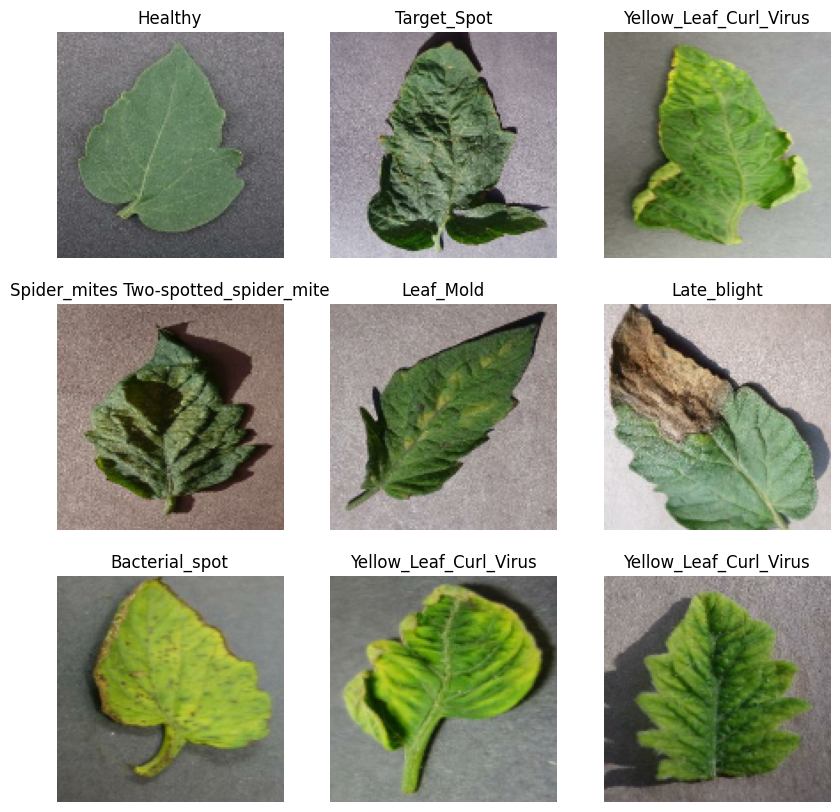

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.5820 - loss: 1.2239 - val_accuracy: 0.8108 - val_loss: 0.5623
Epoch 2/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7682 - loss: 0.6811 - val_accuracy: 0.8615 - val_loss: 0.4399
Epoch 3/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8267 - loss: 0.5046 - val_accuracy: 0.8623 - val_loss: 0.3786
Epoch 4/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8540 - loss: 0.4215 - val_accuracy: 0.8885 - val_loss: 0.3196
Epoch 5/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8795 - loss: 0.3486 - val_accuracy: 0.9138 - val_loss: 0.2449


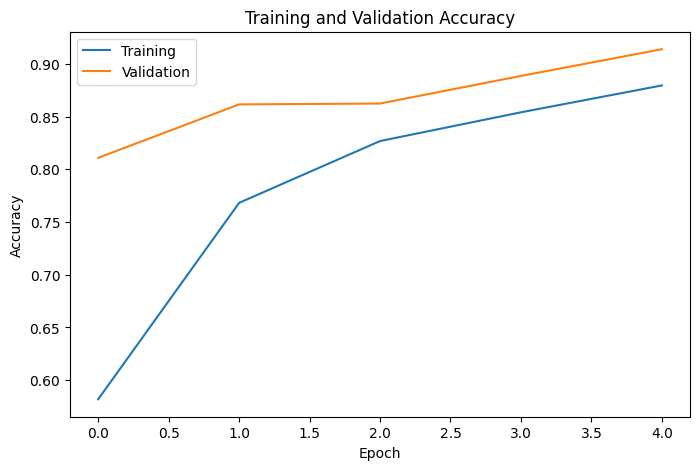

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend(["Training", "Validation"])

plt.show()

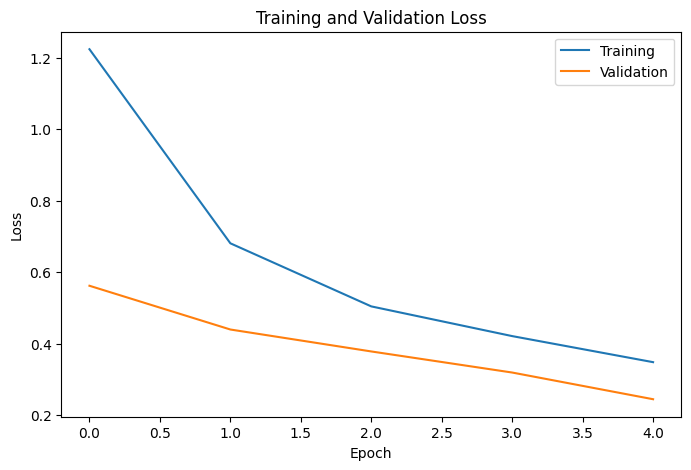

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend(["Training", "Validation"])

plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9138 - loss: 0.2449
Validation Loss: 0.24493379890918732
Validation Accuracy: 0.9138215780258179


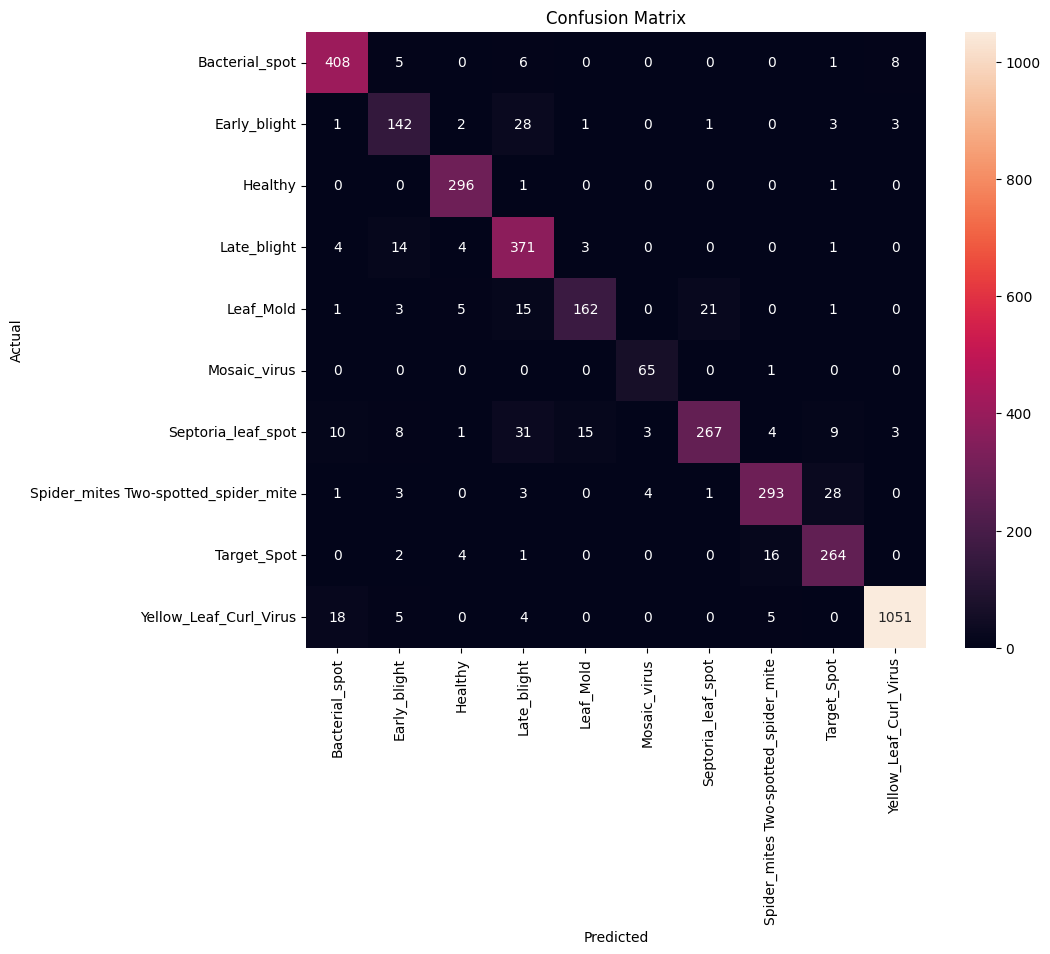

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                      precision    recall  f1-score   support

                      Bacterial_spot       0.92      0.95      0.94       428
                        Early_blight       0.78      0.78      0.78       181
                             Healthy       0.95      0.99      0.97       298
                         Late_blight       0.81      0.93      0.87       397
                           Leaf_Mold       0.90      0.78      0.83       208
                        Mosaic_virus       0.90      0.98      0.94        66
                  Septoria_leaf_spot       0.92      0.76      0.83       351
Spider_mites Two-spotted_spider_mite       0.92      0.88      0.90       333
                         Target_Spot       0.86      0.92      0.89       287
              Yellow_Leaf_Curl_Virus       0.99      0.97      0.98      1083

                            accuracy                           0.91      3632
                           macro avg       0.89      0.90     

In [ ]:
model.save("/content/tomato_disease_cnn.keras")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving image (9).JPG to image (9).JPG


In [ ]:
img_path = list(uploaded.keys())[0]

img = tf.keras.utils.load_img(
    img_path,
    target_size=img_size
)

img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step
Predicted Disease: Septoria_leaf_spot
Confidence: 99.25 %


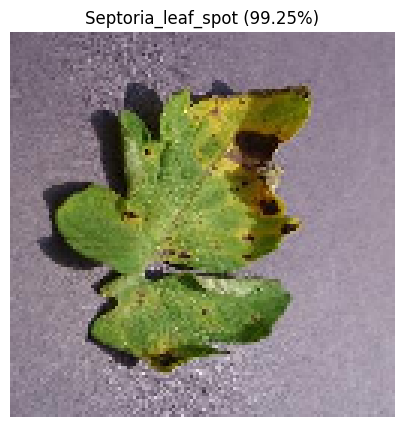

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()